# Chromatin Loops Heterogeneity - Non-Neurons

This notebook analyzes heterogeneity in chromatin loops between and within healthy control and schizophrenia groups using Jaccard similarity metrics.

In [ ]:
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import fclusterdata
import numpy as np
from sklearn.cluster import DBSCAN
from os import listdir
from tqdm import tqdm
import matplotlib.pyplot as plt
from intervaltree import Interval, IntervalTree
from collections import Counter
from itertools import chain, combinations
import os
import glob
import json
import time
import seaborn as sns
import cooler
import bioframe
import cooltools
from cooltools.lib.numutils import fill_diag
from statsmodels.stats.multitest import multipletests
from os.path import isfile, join, basename
from io import StringIO
import pickle
from concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutor
import warnings
from scipy.stats import mannwhitneyu
import matplotlib as mpl
from dotenv import load_dotenv
import pybedtools

warnings.simplefilter(action='ignore', category=FutureWarning)
load_dotenv()
assert os.environ['CONDA_DEFAULT_ENV'] == "hic"

In [ ]:
path_to_maps = os.getenv("PATH_TO_PROCESSED_MAPS")
path_to_loops = "./loops_cooltools_data/"

In [50]:
chromnames = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13',
 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22']
def filer_df(df):
    return df[df['chrom1'].isin(chromnames)]

In [ ]:
def slop_bedpe(df, slop=22500):
    """Extend both anchors of BEDPE by ±slop."""
    df = df.copy()
    df['start1'] = df['start1'] - slop
    df['end1'] = df['end1'] + slop
    df['start2'] = df['start2'] - slop
    df['end2'] = df['end2'] + slop
    df['start1'] = df['start1'].clip(lower=0)
    df['start2'] = df['start2'].clip(lower=0)
    return df

In [ ]:
samples = ['HC-2Mminus',
 'HC-318plus',
 'HC-3Mplus',
 'HC-91plus',
 'HC24plus',
 'HCM12plus',
 'SZ-01plus',
 'SZ-03plus',
 'SZ08plus',
 'SZ10plus',
 'SZ20plus',
 'SZ6plus']
samples = [i.replace('plus', 'minus') for i in samples]

path_to_loops_intensities = "./loops_cooltools_data/loops_temp_files/"
all_files = []
for sample in samples:
    if "318" in sample:
        df= pd.read_feather(f"{path_to_loops_intensities}/{sample}_drop_diag_1kb_dots_final_12000000maxloci_0.13fdr_15000res_small_NaN5.feather")
    else:
        df= pd.read_feather(f"{path_to_loops_intensities}/{sample}_sampled_drop_diag_1kb_dots_final_12000000maxloci_0.13fdr_15000res_small_NaN5.feather")
    df = filer_df(df)
    df=slop_bedpe(df)
    print(df.shape)
    fname = f"{path_to_loops_intensities}/{sample}_15kb_cooltools_loops_slopped1.5.bedpe"
    df[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']].to_csv(fname, sep='\t', header=False, index=False)
    all_files.append(fname)

In [53]:
hc_files = [i for i in all_files if "HC" in i]
sz_files = [i for i in all_files if "SZ" in i]
len(sz_files), len(hc_files)

(6, 6)

In [ ]:
def set_jaccard(bedpe1, bedpe2, slop=0):
    """Compute Jaccard index for two BEDPE files using pybedtools."""
    A = pybedtools.BedTool(bedpe1)
    B = pybedtools.BedTool(bedpe2)
    intersect = A.pair_to_pair(B, slop=slop, type='either', is_sorted=False)
    overlap_loops = set((f[0], int(f[1]), int(f[2]), f[3], int(f[4]), int(f[5])) for f in intersect)
    loops_A = set((f[0], int(f[1]), int(f[2]), f[3], int(f[4]), int(f[5])) for f in A)
    loops_B = set((f[0], int(f[1]), int(f[2]), f[3], int(f[4]), int(f[5])) for f in B)
    union_loops = loops_A | loops_B
    if len(union_loops) == 0:
        return 0
    return len(overlap_loops) / len(union_loops)

def pairwise_set_jaccard(bed_files):
    n = len(bed_files)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i <= j:
                jac = set_jaccard(bed_files[i], bed_files[j])
                matrix[i, j] = jac
                matrix[j, i] = jac
    return matrix

In [55]:
hc_matrix = pairwise_set_jaccard(hc_files)
sz_matrix = pairwise_set_jaccard(sz_files)
all_matrix = pairwise_set_jaccard(all_files)

In [ ]:
samples_with_age = {
    'HC-2M': 62,
    'HC-3M': 36,
    'HC-91': 59,
    'HC24': 54,
    'HC-318': 58,
    'HCM12': 35,
    'SZ-01': 36,
    'SZ-03': 57,
    'SZ08': 56,
    'SZ10': 50,
    'SZ20': 37,
    'SZ6': 62
}
age_group = {}
for label, age in samples_with_age.items():
    if age <= 40:
        age_group[label] = "Adult"
    elif 40 < age <= 57:
        age_group[label] = "Old"
    else:
        age_group[label] = "Old"

def extract_sample_name(filename):
    try:
        core = filename.split('minus')[0]
        core = core.rstrip('_')
        return core
    except:
        print(filename)

def get_sorted_labels_and_indices(labels, samples_with_age):
    paired = [(label, samples_with_age[label]) for label in labels]
    paired_sorted = sorted(paired, key=lambda x: x[1])
    sorted_labels = [p[0] for p in paired_sorted]
    sorted_indices = [labels.index(lab) for lab in sorted_labels]
    return sorted_labels, sorted_indices

def make_label(label):
    age = samples_with_age[label]
    group = age_group[label]
    short = label
    return f"{short}\n{age}y\n{group}"

def plot_heatmap(matrix, labels, title, samples_with_age, figsize=(6, 5)):
    sns.set_theme(style='ticks')
    sorted_labels, sorted_indices = get_sorted_labels_and_indices(labels, samples_with_age)
    sorted_matrix = matrix[np.ix_(sorted_indices, sorted_indices)]
    annotated_labels = [make_label(lab) for lab in sorted_labels]
    df = pd.DataFrame(sorted_matrix, index=annotated_labels, columns=annotated_labels)
    min_val = np.min(sorted_matrix)
    max_val = 0.5
    plt.figure(figsize=figsize)
    sns.heatmap(
        df,
        annot=True,
        cmap='YlGnBu',
        vmin=min_val,
        vmax=max_val,
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "Set-based Jaccard Index"}
    )
    plt.title(title, fontsize=16)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

hc_labels = [extract_sample_name(os.path.basename(f)) for f in hc_files]
sz_labels = [extract_sample_name(os.path.basename(f)) for f in sz_files]
all_labels = [extract_sample_name(os.path.basename(f)) for f in all_files]

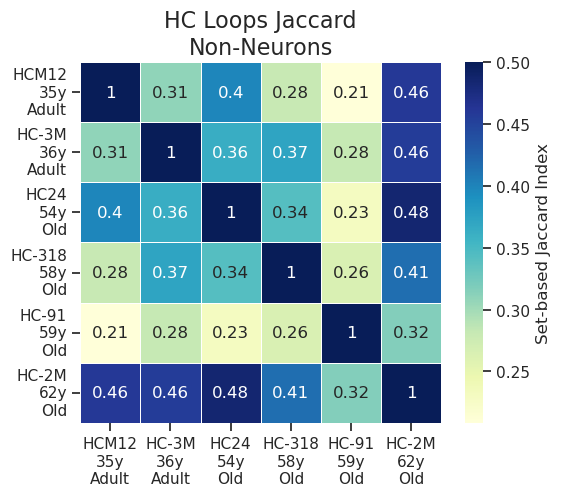

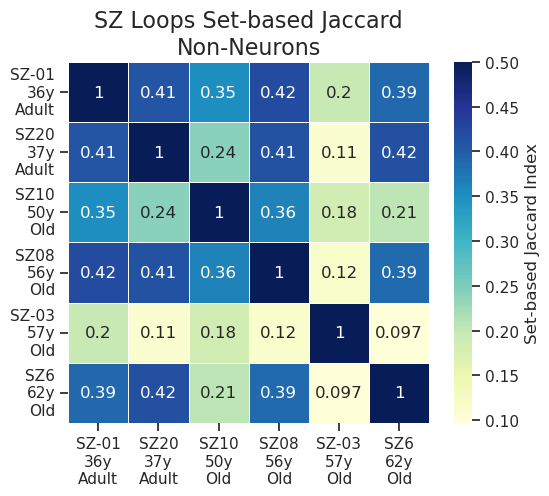

In [57]:
plot_heatmap(hc_matrix, hc_labels, 'HC Loops Jaccard\nNon-Neurons', samples_with_age)
plot_heatmap(sz_matrix, sz_labels, 'SZ Loops Set-based Jaccard\nNon-Neurons', samples_with_age)

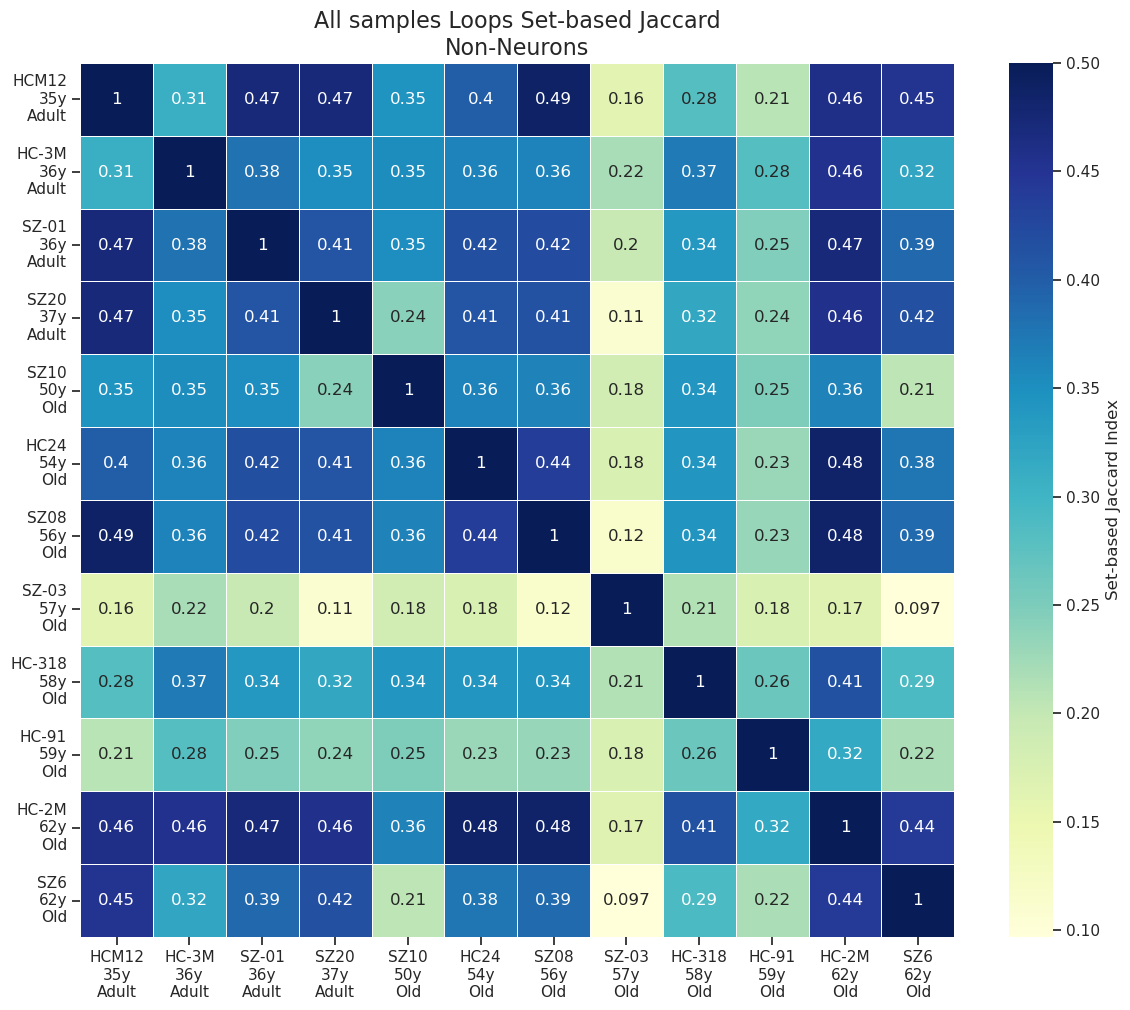

In [58]:
plot_heatmap(all_matrix, all_labels, 'All samples Loops Set-based Jaccard\nNon-Neurons', samples_with_age, figsize=(12, 10))

In [ ]:
# Box Plots

In [ ]:
def get_group(label):
    if label.startswith('HC'):
        return 'HC'
    elif label.startswith('SZ'):
        return 'SZ'
    else:
        return 'Other'

def significance_label(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

all_matrix_set = all_matrix.copy()
all_labels_set = all_labels.copy()
groups = [get_group(label) for label in all_labels_set]

In [68]:
data = []
n = len(all_labels_set)
for i in range(n):
    for j in range(i+1, n):
        sim = all_matrix_set[i, j]
        group_i = groups[i]
        group_j = groups[j]
        if group_i == group_j == 'HC':
            cat = 'Within HC'
        elif group_i == group_j == 'SZ':
            cat = 'Within SZ'
        elif (group_i == 'HC' and group_j == 'SZ') or (group_i == 'SZ' and group_j == 'HC'):
            cat = 'Between HC-SZ'
        else:
            continue
        data.append({'similarity': sim, 'category': cat})

df = pd.DataFrame(data)
order = ['Within HC', 'Within SZ', 'Between HC-SZ']


In [ ]:
my_pal = {
    "Within HC": '#469433',
    "Within SZ":  '#e38519',
    "Between HC-SZ": "lightgrey"
}

cat_labels = ['Within HC', 'Within SZ', 'Between HC-SZ']
pvals = {}
for cat1, cat2 in combinations(cat_labels, 2):
    group1 = df[df['category'] == cat1]['similarity']
    group2 = df[df['category'] == cat2]['similarity']
    stat, pval = mannwhitneyu(group1, group2, alternative='two-sided')
    pvals[(cat1, cat2)] = pval

sns.set(style="whitegrid")
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['axes.labelsize'] = 8
mpl.rcParams['xtick.labelsize'] = 8
mpl.rcParams['ytick.labelsize'] = 8
plt.rcParams["svg.fonttype"] = "none"

plt.figure(figsize=( 3.5, 6.54))
ax = sns.boxplot(
    x='category', y='similarity', data=df, order=order,
    palette=my_pal, showfliers=False, linewidth=0.4, width=0.4,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "grey",
        "markersize": 6,
        "markeredgewidth": 2
    }
)

ax.set_xlabel('')
ax.set_ylabel('Jaccard Similarity', labelpad=10)
ax.set_ylim(0.05, 0.55)

y_max = df['similarity'].max()
y_min = df['similarity'].min()
h = (y_max - y_min) * 0.04

pairs = [
    (0, 1),
    (0, 2),
    (1, 2)
]
for idx, ((cat1, cat2), (i, j)) in enumerate(zip(pvals.keys(), pairs)):
    y = y_max + h*idx
    x1, x2 = i, j
    pval = pvals[(cat1, cat2)]
    label = significance_label(pval) + f" (p={round(pval,2)})"
    ax.plot([x1, x1, x2, x2], [y, y+h/4, y+h/4, y], lw=0.4, c='k')
    ax.text((x1+x2)/2, y+h/4, label, ha='center', va='bottom', fontsize=8)

plt.tight_layout()
cell_type = "non_neurons"
plt.savefig(f'./loops_visualizations/loops_{cell_type}_jaccard_similarity_groups_pubready.svg', dpi=300)
plt.savefig(f'./loops_visualizations/loops_{cell_type}_jaccard_similarity_groups_pubready.pdf', dpi=300)

plt.show()

In [ ]:
# Clustermap

In [ ]:
def make_label(label):
    age = samples_with_age[label]
    group = age_group[label]
    short = label
    return f"{short}\n{age}y\n{group}"

def plot_clustermap(matrix, labels, title, samples_with_age, figsize=(8, 8)):
    annotated_labels = [make_label(lab) for lab in labels]
    distance_matrix = matrix
    sorted_labels, sorted_indices = get_sorted_labels_and_indices(labels, samples_with_age)
    sorted_matrix = matrix[np.ix_(sorted_indices, sorted_indices)]
    min_val = np.min(sorted_matrix)
    max_val = 0.4
    df = pd.DataFrame(distance_matrix, index=annotated_labels, columns=annotated_labels)
    cg = sns.clustermap(
        df,
        cmap='YlGnBu',
        linewidths=0.5,
        figsize=figsize,
        vmin=min_val,
        vmax=max_val,
        annot=True,
        cbar_kws={"label": "Jaccard"},
        metric='euclidean',
        method='average',
    )
    plt.suptitle(title, fontsize=16)
    plt.show()

plot_clustermap(all_matrix, all_labels, 'All samples Loops Set-based Jaccard\nNon-Neurons', samples_with_age, figsize=(12, 10))

In [60]:
def get_off_diagonal(matrix):
    n = matrix.shape[0]
    return [matrix[i, j] for i in range(n) for j in range(n) if i != j]


Mann-Whitney U statistic: 560.000
p-value: 1.053e-01
HC mean: 0.345, median: 0.342
SZ mean: 0.287, median: 0.351


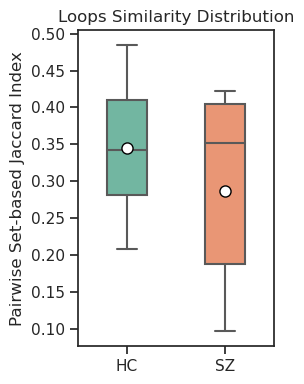

In [61]:
hc_similarities = get_off_diagonal(hc_matrix)
sz_similarities = get_off_diagonal(sz_matrix)

stat, p_value = mannwhitneyu(hc_similarities, sz_similarities, alternative='two-sided')
print(f"Mann-Whitney U statistic: {stat:.3f}")
print(f"p-value: {p_value:.3e}")

print(f"HC mean: {np.mean(hc_similarities):.3f}, median: {np.median(hc_similarities):.3f}")
print(f"SZ mean: {np.mean(sz_similarities):.3f}, median: {np.median(sz_similarities):.3f}")

plt.figure(figsize=(3, 4))
sns.boxplot(
    data=[hc_similarities, sz_similarities],
    
    width=0.4,
    palette='Set2',
    # palette={'HC': 'skyblue', 'SZ': 'salmon'},
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "8"
    }
)
plt.xticks([0, 1], ['HC', 'SZ'])
plt.ylabel('Pairwise Set-based Jaccard Index')
plt.title('Loops Similarity Distribution')
plt.tight_layout()
plt.show()

In [ ]:
def pairwise_similarity_df(matrix, labels):
    data = []
    n = len(labels)
    for i in range(n):
        for j in range(i+1, n):
            sim = matrix[i, j]
            label_i, label_j = labels[i], labels[j]
            group_i, group_j = get_group(label_i), get_group(label_j)
            age_i, age_j = age_group[label_i], age_group[label_j]
            data.append({
                'sample1': label_i, 'sample2': label_j,
                'group1': group_i, 'group2': group_j,
                'age_group1': age_i, 'age_group2': age_j,
                'similarity': sim
            })
    return pd.DataFrame(data)

def get_group(label):
    if label.startswith('HC'):
        return 'HC'
    elif label.startswith('SZ'):
        return 'SZ'
    else:
        return 'Unknown'

samples_with_age = {
    'HC-2M': 62, 'HC-3M': 36, 'HC-91': 59, 'HC24': 54, 'HC-318': 58, 'HCM12': 35,
    'SZ-01': 36, 'SZ-03': 57, 'SZ08': 56, 'SZ10': 50, 'SZ20': 37, 'SZ6': 62
}
age_group = {}
for label, age in samples_with_age.items():
    if age <= 40:
        age_group[label] = "Adult"
    elif 40 < age <= 57:
        age_group[label] = "Old"
    else:
        age_group[label] = "Old"

hc_df = pairwise_similarity_df(hc_matrix, hc_labels)
sz_df = pairwise_similarity_df(sz_matrix, sz_labels)
all_df = pd.concat([hc_df, sz_df], ignore_index=True)

In [63]:
age_comparison = ['Adult-Old', 'Old-Old', 'Adult-Adult']

all_df['comparison'] = all_df['age_group1'] + all_df['age_group2']
age_comparison_list = []
for i in all_df['comparison']:
    if "Adult" in i and "Old" in i:
        age_comparison_list.append('Adult-Old')
    elif "Adult" in i and "Old" not in i:
        age_comparison_list.append('Adult-Adult')
    else:
        age_comparison_list.append('Old-Old')
all_df['comparison'] = age_comparison_list
all_df['group'] = all_df['group2']


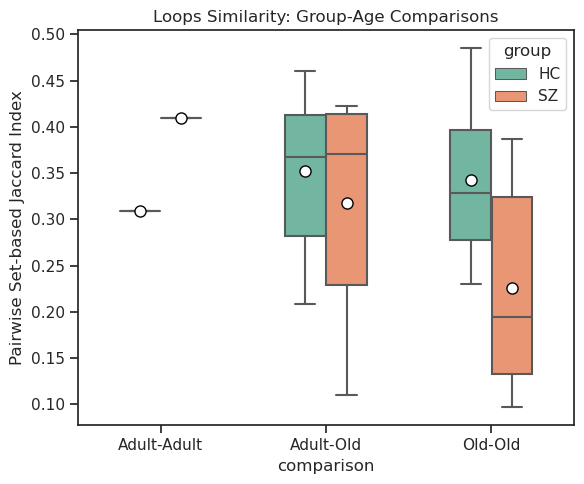

In [64]:
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=all_df,
    x=all_df.comparison,
    y=all_df.similarity,
    hue = "group",
    order = [ 'Adult-Adult','Adult-Old', 'Old-Old'],

    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "8"
    },
    width=0.5,
    palette='Set2'
)
plt.ylabel('Pairwise Set-based Jaccard Index')
plt.title('Loops Similarity: Group-Age Comparisons')
plt.tight_layout()
plt.show()